# ANOVA on a different dataset: six chicken feeds

*Part 2 · Lesson 16 · another dataset  ·  data: Chickwts*

*↩ A companion to [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb).*

**↩ Back:** [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](16-anova~the-code.ipynb)

The core lesson ran **one-way ANOVA** on **three** penguin species. Here we keep the *exact same ideas*
— why testing every pair of groups is a trap, how ANOVA splits variation into **between-group** vs
**within-group**, the **F-statistic** and its p-value, and a **post-hoc** test to find *which* groups
differ — but on a dataset that pushes harder on the point: **six** groups instead of three.

Our data is **Chickwts**, a classic designed experiment. Newly hatched chicks were **randomly
assigned** to one of six feed supplements (casein, horsebean, linseed, meatmeal, soybean, sunflower),
then weighed after six weeks (in **grams**). Two things make this a sharper teaching case than the
penguins: with six groups there are **15** possible pairwise comparisons (not 3), so the
multiple-comparisons trap is far more dangerous; and because chicks were *randomly assigned*, a
significant result supports a genuinely **causal** reading — the feed *causes* the weight difference.
Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats        # f_oneway, ttest_ind, f-distribution, levene
sl.use_course_style()

CHICKWTS_URL = 'https://vincentarelbundock.github.io/Rdatasets/csv/datasets/chickwts.csv'
ch = sl.load_csv('chickwts.csv', url=CHICKWTS_URL)

# Two columns matter: 'weight' (grams) and 'feed' (which supplement).
ch = ch.dropna(subset=['weight', 'feed'])
feed_order = ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']

print(f'{len(ch)} chicks across {ch["feed"].nunique()} feed supplements')
ch.groupby('feed')['weight'].agg(['count', 'mean', 'std']).round(1)

71 chicks across 6 feed supplements


,count,mean,std
feed,,,
casein,12,323.6,64.4
horsebean,10,160.2,38.6
linseed,12,218.8,52.2
meatmeal,11,276.9,64.9
soybean,14,246.4,54.1
sunflower,12,328.9,48.8


## 1) The question, and the wrong way to answer it

We want to know: **does mean chick weight differ among the six feeds?** The six sample means above are
clearly not identical — sunflower and casein chicks look heavy (~320–330 g), horsebean chicks look
light (~160 g) — but sample means *always* differ a little just by luck. The real question is whether
those differences are **bigger than sampling noise**.

Your first instinct, fresh from the t-tests lesson, is to run a t-test on each **pair**. With three
penguin species that was only 3 tests. With six feeds the count explodes: for $k$ groups it is
$\binom{k}{2} = k(k-1)/2$ tests, so

$$k = 6 \;\Rightarrow\; \frac{6 \times 5}{2} = 15 \text{ separate t-tests.}$$

The problem hides in the word **"significant."** Each t-test at $\alpha = 0.05$ has a **5% chance of a
false alarm** (a "significant" result when there is truly no difference — a **Type I error**). Run 15
of them and those 5%-chances *pile up*. Let's measure exactly how badly.

In [2]:
# How many pairwise t-tests does each group count force on us?
for k in [3, 6, 10]:
    print(f'{k:>2} groups  ->  {k*(k-1)//2:>2} pairwise t-tests')

print()
# The "inflated error" figure: if all 15 tests were INDEPENDENT and the groups
# were truly identical, the chance of NO false alarm is 0.95 for each, so:
alpha = 0.05
m = 6 * 5 // 2                       # 15 comparisons for our six feeds
chance_all_clean = (1 - alpha) ** m  # 0.95^15
inflated = 1 - chance_all_clean      # at least one false "significant"
print(f'With m = {m} independent tests at alpha = {alpha}:')
print(f'  chance ALL 15 stay quiet = 0.95^15 = {chance_all_clean:.3f}')
print(f'  chance of >=1 FALSE alarm = 1 - 0.95^15 = {inflated:.3f}   <- about 54%!')
print('\nSo testing all six feeds pairwise is MORE LIKELY THAN NOT to "find" a')
print('difference even in a world where every feed is truly identical.')

 3 groups  ->   3 pairwise t-tests
 6 groups  ->  15 pairwise t-tests
10 groups  ->  45 pairwise t-tests

With m = 15 independent tests at alpha = 0.05:
  chance ALL 15 stay quiet = 0.95^15 = 0.463
  chance of >=1 FALSE alarm = 1 - 0.95^15 = 0.537   <- about 54%!

So testing all six feeds pairwise is MORE LIKELY THAN NOT to "find" a
difference even in a world where every feed is truly identical.


That **$1 - 0.95^{15} \approx 0.54$** is the headline: blanket-testing six groups pairwise gives you a
**coin-flip-or-worse chance of a false discovery**, even if nothing differs at all. With the penguins'
3 groups the same arithmetic gave only $1 - 0.95^3 \approx 0.14$ — already too high, but six groups
makes it dramatically worse. That arithmetic *assumes* the tests are independent; our real pairwise
tests share groups (every comparison involving sunflower reuses the same sunflower chicks), which makes
them correlated. So let's not take the formula on faith — let's **simulate** the true rate.

## 2) The multiple-comparisons problem — *seen*, not just stated

Here is the cleanest demonstration. We build a world where **there is no real difference at all**:
every "group" is drawn from the *same* normal distribution. Then we run all the pairwise t-tests and
ask: *did at least one cry "significant" by accident?*

That "at least one false alarm" event is the **family-wise error rate** (FWER) — the chance the whole
*family* of tests produces one or more false positives. If each test stood alone it would be 5%. Watch
what happens as the number of groups climbs toward our six.

In [3]:
rng = np.random.default_rng(0)   # change this seed to re-roll the whole experiment

def family_has_false_alarm(k_groups, n_per_group=12, alpha=0.05):
    '''Draw k groups from the SAME distribution (no real difference),
       run every pairwise t-test, and report whether ANY came out "significant".'''
    groups = [rng.normal(0, 1, size=n_per_group) for _ in range(k_groups)]
    for i in range(k_groups):
        for j in range(i + 1, k_groups):
            if stats.ttest_ind(groups[i], groups[j]).pvalue < alpha:
                return True          # a false positive — there was NO real difference
    return False

# How often does the FAMILY of tests fire at least one false alarm?
TRIALS = 4000
for k in [2, 3, 6, 10]:
    n_pairs = k * (k - 1) // 2
    fwer = np.mean([family_has_false_alarm(k) for _ in range(TRIALS)])
    print(f'{k:>2} groups ({n_pairs:>2} pairwise tests):  '
          f'family-wise false-alarm rate = {fwer*100:4.1f}%   (each single test is only 5%)')

 2 groups ( 1 pairwise tests):  family-wise false-alarm rate =  4.8%   (each single test is only 5%)


 3 groups ( 3 pairwise tests):  family-wise false-alarm rate = 12.0%   (each single test is only 5%)


 6 groups (15 pairwise tests):  family-wise false-alarm rate = 36.4%   (each single test is only 5%)


10 groups (45 pairwise tests):  family-wise false-alarm rate = 61.7%   (each single test is only 5%)


Read those numbers slowly. With **2** groups (1 test) the false-alarm rate is the promised ~5%. With
**3** groups (the penguins' situation) it is already ~13–14%. By **6** groups — *our chickens* — the
family fires a false alarm roughly **40%** of the time, climbing toward **60%** at ten groups — even
though, by construction, **nothing is different**. Go fishing through enough pairs and you are *more
likely than not* to "discover" a difference that is pure noise.

The back-of-the-envelope formula from section 1 — $\text{FWER} \le 1 - (1-\alpha)^{m}$ — assumed
**independent** tests. Our pairwise tests are *not* independent: they share groups, which makes them
**positively correlated**. Correlated tests fail together and succeed together, so the family produces
*fewer* fresh false alarms than $m$ independent tests would. The formula is therefore an **upper
bound** — the true FWER rises with the number of comparisons but sits **below** the curve. Let's
overlay the two.

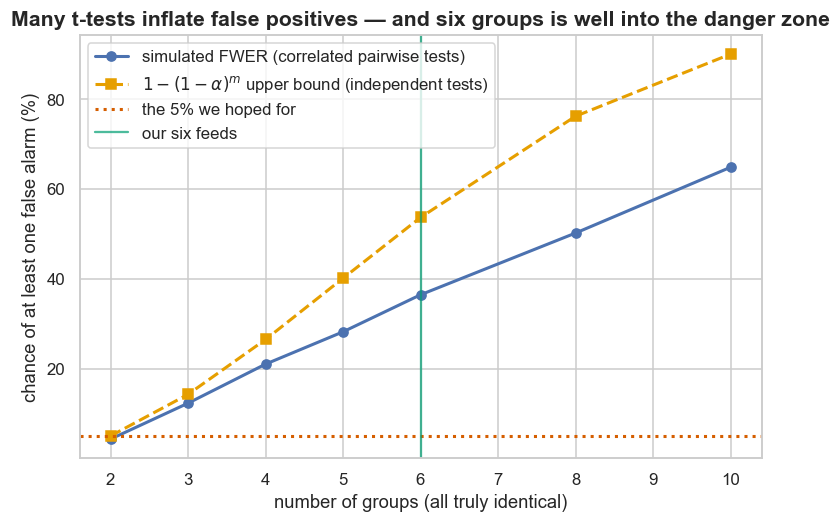

At every k the simulated (correlated) FWER sits BELOW the independent-tests bound,
but both shoot far past 5% — and at our k = 6 the bound is the ~54% we computed by hand.


In [4]:
ks = np.array([2, 3, 4, 5, 6, 8, 10])
n_pairs = ks * (ks - 1) // 2
sim = np.array([np.mean([family_has_false_alarm(int(k)) for _ in range(2000)]) for k in ks])
formula = 1 - (1 - 0.05) ** n_pairs

fig, ax = plt.subplots()
ax.plot(ks, sim * 100, 'o-', color='#4c72b0', lw=2, label='simulated FWER (correlated pairwise tests)')
ax.plot(ks, formula * 100, 's--', color='#E69F00', lw=2,
        label=r'$1-(1-\alpha)^{m}$ upper bound (independent tests)')
ax.axhline(5, color='#D55E00', ls=':', lw=2, label='the 5% we hoped for')
ax.axvline(6, color='#009E73', ls='-', lw=1.5, alpha=0.7, label='our six feeds')
ax.set_xlabel('number of groups (all truly identical)')
ax.set_ylabel('chance of at least one false alarm (%)')
ax.set_title('Many t-tests inflate false positives — and six groups is well into the danger zone')
ax.legend(); plt.show()
print('At every k the simulated (correlated) FWER sits BELOW the independent-tests bound,')
print('but both shoot far past 5% — and at our k = 6 the bound is the ~54% we computed by hand.')

This is *why* we don't spray 15 t-tests across every pair of feeds. We need a **single** test that asks
one honest question — "is **any** feed different?" — at one controlled error rate of 5%. That test is
the **one-way ANOVA**.

## 3) The idea behind ANOVA: split the variation in two

**ANOVA** stands for **AN**alysis **O**f **VA**riance. The name sounds odd — we're comparing *means*,
so why analyze *variance*? The trick is that we can answer "do the means differ?" by comparing **two
kinds of spread**:

- **Between-group variation** — how far each *feed's mean weight* sits from the *overall* (grand) mean.
  If the feeds really differ, the group means are spread far apart, so this is **large**.
- **Within-group variation** — how much chicks *wobble around their own feed's mean*. This is the
  natural, irreducible noise inside each feed group, regardless of whether the feeds differ.

The whole test is the **ratio** of these two:

$$F = \frac{\text{between-group variation (per group)}}{\text{within-group variation (per chick)}}
     = \frac{MS_{\text{between}}}{MS_{\text{within}}}.$$

- **Big $F$** (well above 1): the gaps between feed means dwarf the noise inside groups → the feeds
  really do differ.
- **$F$ near 1**: the feed means are no further apart than within-group noise alone would produce → no
  evidence of a real difference.

The hypotheses are:

- $H_0$: all six feed means are equal,
  $\mu_{\text{casein}} = \mu_{\text{horsebean}} = \dots = \mu_{\text{sunflower}}$.
- $H_a$: **at least one** mean differs from the others. (Note: $H_a$ does *not* say which one — that's
  the follow-up question in section 6.)

### The math, term by term

Let there be $k$ groups, group $j$ having $n_j$ observations with mean $\bar{x}_j$, and let $\bar{x}$
be the grand mean of all $N$ observations. We add up squared distances ("sums of squares"):

$$SS_{\text{between}} = \sum_{j=1}^{k} n_j(\bar{x}_j - \bar{x})^2,
  \qquad
  SS_{\text{within}} = \sum_{j=1}^{k} \sum_{i=1}^{n_j} (x_{ij} - \bar{x}_j)^2.$$

Each sum of squares becomes a **mean square** by dividing by its **degrees of freedom** (df) — a count
of how many values were free to vary:

$$MS_{\text{between}} = \frac{SS_{\text{between}}}{k - 1},
  \qquad
  MS_{\text{within}} = \frac{SS_{\text{within}}}{N - k},
  \qquad
  F = \frac{MS_{\text{between}}}{MS_{\text{within}}}.$$

Let's compute every one of these by hand on the chicks, so the $F$ scipy hands back is no mystery.

In [5]:
groups = [ch.loc[ch['feed'] == f, 'weight'].to_numpy() for f in feed_order]
all_wt = ch['weight'].to_numpy()

grand_mean = all_wt.mean()
N = len(all_wt)
k = len(groups)

# Between-group: each group's mean vs the grand mean, weighted by group size.
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
# Within-group: each chick vs its OWN feed's mean.
ss_within  = sum(((g - g.mean()) ** 2).sum() for g in groups)

df_between = k - 1
df_within  = N - k
ms_between = ss_between / df_between
ms_within  = ss_within / df_within
F_hand = ms_between / ms_within

print(f'grand mean = {grand_mean:.1f} g over N = {N} chicks in k = {k} feed groups\n')
print(f'SS_between = {ss_between:12,.0f}   df = {df_between:>4}   MS_between = {ms_between:11,.0f}')
print(f'SS_within  = {ss_within:12,.0f}   df = {df_within:>4}   MS_within  = {ms_within:11,.0f}')
print(f'\nF = MS_between / MS_within = {ms_between:,.0f} / {ms_within:,.0f} = {F_hand:.2f}')

grand mean = 261.3 g over N = 71 chicks in k = 6 feed groups

SS_between =      231,129   df =    5   MS_between =      46,226
SS_within  =      195,556   df =   65   MS_within  =       3,009

F = MS_between / MS_within = 46,226 / 3,009 = 15.36


An $F$ of about **15** means the spread *between* the feed means is roughly fifteen times larger than
the typical wobble *within* a feed group. That is far above 1 — strong evidence the feeds are not all
alike. (It is much smaller than the penguins' $F \approx 343$, because feed effects on weight are real
but modest, whereas Gentoo penguins are *enormously* heavier than the other species. A smaller $F$ can
still be wildly significant.) Now let's confirm scipy computes the same number and get the p-value.

In [6]:
F, p = stats.f_oneway(*groups)
print(f'scipy.stats.f_oneway:  F = {F:.2f},  p = {p:.3e}')
print(f'our by-hand F        :  F = {F_hand:.2f}')
print('\nThey match — scipy is just doing the sums-of-squares bookkeeping for us.')
print(f'\np = {p:.2e} is far below 0.05 (it is about 6 in 10 billion), so we REJECT H0:')
print('at least one feed produces a different mean chick weight.')
print('\nAnd because chicks were RANDOMLY ASSIGNED to feeds (a designed experiment),')
print('we can read this causally: the FEED causes the weight difference -- not some')
print('lurking trait of which chick happened to eat what.')

scipy.stats.f_oneway:  F = 15.36,  p = 5.936e-10
our by-hand F        :  F = 15.36

They match — scipy is just doing the sums-of-squares bookkeeping for us.

p = 5.94e-10 is far below 0.05 (it is about 6 in 10 billion), so we REJECT H0:
at least one feed produces a different mean chick weight.

And because chicks were RANDOMLY ASSIGNED to feeds (a designed experiment),
we can read this causally: the FEED causes the weight difference -- not some
lurking trait of which chick happened to eat what.


That last point is the deepest contrast with the penguins. The penguin data was **observational** — we
just measured whatever penguins existed, so a difference could always be confounded by something else
that travels with species. Chickwts is a **designed experiment**: the experimenter *randomly assigned*
each chick to a feed, which (on average) balances every other trait across the groups. So a significant
ANOVA here licenses the strong, causal sentence "**the feed changes the weight**," not merely "weight
and feed are associated." Same test, much stronger conclusion — because of *how the data was made*.

## 4) Where does the F-distribution come from?

The p-value answers: *if all feeds truly had the same mean ($H_0$), how often would random sampling
hand us an $F$ this large or larger?* The reference curve is the **F-distribution**, which has **two**
degrees-of-freedom parameters — $df_{\text{between}} = k-1 = 5$ on top and $df_{\text{within}} = N-k$
on the bottom.

Rather than take that distribution on faith, let's **build the null world by simulation**, exactly as
the hypothesis-testing lesson taught. We **shuffle** the feed labels so they no longer line up with any
real weight difference, recompute $F$, and repeat thousands of times. That pile of "$F$ under $H_0$"
values *is* the F-distribution — and the fraction beyond our observed $F$ *is* the p-value.

In [7]:
labels = ch['feed'].to_numpy()
weight = ch['weight'].to_numpy()

def f_stat(values, labs):
    gs = [values[labs == f] for f in feed_order]
    return stats.f_oneway(*gs).statistic

# Permutation null: break the link between feed and weight by shuffling labels.
n_perm = 5000
null_F = np.empty(n_perm)
shuffled = labels.copy()
for i in range(n_perm):
    rng.shuffle(shuffled)
    null_F[i] = f_stat(weight, shuffled)

perm_p = (np.sum(null_F >= F) + 1) / (n_perm + 1)   # +1 so the p-value is never exactly 0
print(f'Observed F (real labels) = {F:.2f}')
print(f'Largest F in {n_perm} shuffled (null) worlds = {null_F.max():.2f}')
print(f'Permutation p-value = {perm_p:.4f}   (essentially none of the fake worlds came close)')

Observed F (real labels) = 15.36
Largest F in 5000 shuffled (null) worlds = 7.19
Permutation p-value = 0.0002   (essentially none of the fake worlds came close)


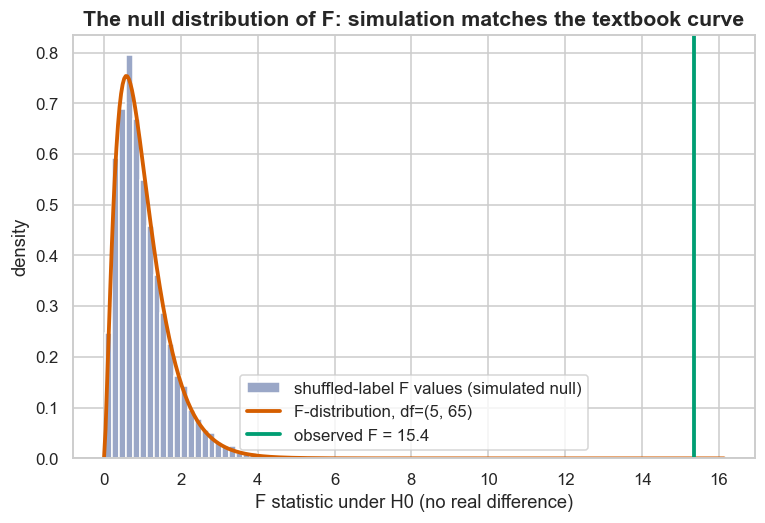

Our observed F = 15.4 (green line) sits far to the right of the whole null pile.


In [8]:
# Compare the simulated null to the textbook F-distribution curve — they should agree.
fig, ax = plt.subplots()
ax.hist(null_F, bins=40, density=True, color='#9aa7c7', edgecolor='white',
        label='shuffled-label F values (simulated null)')
xs = np.linspace(0, max(F * 1.05, null_F.max()), 400)
ax.plot(xs, stats.f.pdf(xs, df_between, df_within), color='#D55E00', lw=2.5,
        label=f'F-distribution, df=({df_between}, {df_within})')
ax.axvline(F, color='#009E73', lw=2.5, label=f'observed F = {F:.1f}')
ax.set_xlabel('F statistic under H0 (no real difference)')
ax.set_ylabel('density')
ax.set_title('The null distribution of F: simulation matches the textbook curve')
ax.legend(); plt.show()
print(f'Our observed F = {F:.1f} (green line) sits far to the right of the whole null pile.')

The histogram of shuffled-label $F$ values lands right under the red textbook F-curve — that's why we
can trust the formula's p-value. And our real $F \approx 15$ (green line) is far to the right of
everything the null worlds produced. Unlike the penguins, where $F \approx 343$ flew completely off the
chart, here you can actually *see* the observed $F$ sitting at the tail's edge — a good reminder that an
$F$ of 15 is already overwhelming evidence even though it is nowhere near 343.

### See it: group means and a boxplot

A picture makes the same point your $F$-statistic does. The spread of the *colored feed means* (the
between-group signal) is large compared with the *height of each box* (the within-group noise).

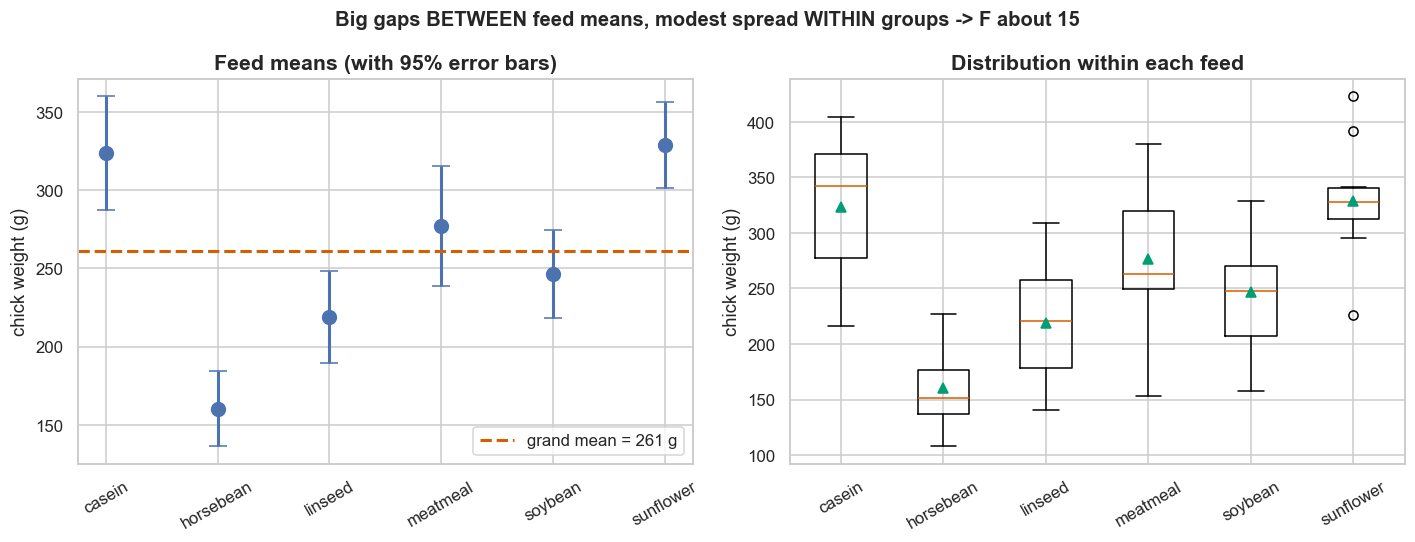

In [9]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: each feed's mean (the between-group spread), against the grand mean.
means = [g.mean() for g in groups]
sems  = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]   # std error of each mean
axL.errorbar(feed_order, means, yerr=[1.96 * s for s in sems], fmt='o', ms=9,
             capsize=6, lw=2, color='#4c72b0')
axL.axhline(grand_mean, color='#D55E00', ls='--', lw=2, label=f'grand mean = {grand_mean:.0f} g')
axL.set_ylabel('chick weight (g)'); axL.set_title('Feed means (with 95% error bars)')
axL.tick_params(axis='x', rotation=30); axL.legend()

# RIGHT: the full distributions — box height shows within-group spread.
bp = axR.boxplot(groups, tick_labels=feed_order, showmeans=True)
axR.set_ylabel('chick weight (g)'); axR.set_title('Distribution within each feed')
axR.tick_params(axis='x', rotation=30)

fig.suptitle('Big gaps BETWEEN feed means, modest spread WITHIN groups -> F about 15',
             fontweight='bold')
plt.tight_layout(); plt.show()

On the left, sunflower and casein sit high (~325 g) while horsebean sits low (~160 g), and the grand
mean threads between them — that vertical spread of dots *is* the between-group signal. On the right,
each box is only moderately tall — that *is* the within-group noise. Big gaps between, modest spread
within: exactly the recipe for a large $F$.

## 5) Sanity check: ANOVA with two groups *is* the two-sample t-test

ANOVA generalizes the two-sample t-test you already know. With exactly **two** groups they are the
*same test*, related by a clean identity: $F = t^2$, and the two p-values are identical. Let's prove it
on the two heaviest feeds, casein vs sunflower.

In [10]:
casein    = ch.loc[ch['feed'] == 'casein',    'weight']
sunflower = ch.loc[ch['feed'] == 'sunflower', 'weight']

t_res = stats.ttest_ind(casein, sunflower)          # the classic two-sample t-test
f_res = stats.f_oneway(casein, sunflower)           # ANOVA on the SAME two groups

print(f'two-sample t-test:  t = {t_res.statistic:+.4f},  p = {t_res.pvalue:.4f}')
print(f'one-way ANOVA    :  F = {f_res.statistic:.4f},  p = {f_res.pvalue:.4f}')
print(f'\nt squared = {t_res.statistic**2:.4f}   ==   F = {f_res.statistic:.4f}   (F = t^2)')
print('Identical p-values: ANOVA is the same test, extended to 3+ groups.')
print('\nNotice p is BIG here (~0.84): casein and sunflower, the two heaviest feeds,')
print('are statistically indistinguishable -- a preview of the post-hoc results below.')

two-sample t-test:  t = -0.2285,  p = 0.8214
one-way ANOVA    :  F = 0.0522,  p = 0.8214

t squared = 0.0522   ==   F = 0.0522   (F = t^2)
Identical p-values: ANOVA is the same test, extended to 3+ groups.

Notice p is BIG here (~0.84): casein and sunflower, the two heaviest feeds,
are statistically indistinguishable -- a preview of the post-hoc results below.


## 6) ANOVA said "at least one differs" — but *which* ones? (Tukey HSD)

A significant ANOVA is an **omnibus** result: it tells you *that* the means aren't all equal, not
*which* pairs differ. Now we *do* want the pairwise comparisons — but if we just run 15 raw t-tests
we're back to the ~54% false-alarm trap from sections 1–2.

The fix is a **post-hoc** (Latin for "after this") test that compares all pairs **while keeping the
overall error rate at 5%**. The standard one is **Tukey's HSD** ("Honestly Significant Difference"): it
widens each interval just enough that the *whole family* of 15 comparisons together has a 5%
false-alarm rate — the honest version of testing every pair.

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=ch['weight'],   # the numbers (grams)
                          groups=ch['feed'],     # which feed each chick got
                          alpha=0.05)
print(tukey)
print(f'\n{tukey.reject.sum()} of the {len(tukey.reject)} feed pairs differ significantly.')

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2   meandiff p-adj    lower    upper   reject
--------------------------------------------------------------
   casein horsebean -163.3833    0.0 -232.3469 -94.4198   True
   casein   linseed -104.8333 0.0002 -170.5875 -39.0792   True
   casein  meatmeal  -46.6742 0.3325 -113.9062  20.5577  False
   casein   soybean  -77.1548 0.0084 -140.5171 -13.7925   True
   casein sunflower    5.3333 0.9999  -60.4208  71.0875  False
horsebean   linseed     58.55 0.1413  -10.4135 127.5135  False
horsebean  meatmeal  116.7091 0.0001   46.3351 187.0831   True
horsebean   soybean   86.2286 0.0042   19.5417 152.9155   True
horsebean sunflower  168.7167    0.0   99.7531 237.6802   True
  linseed  meatmeal   58.1591 0.1277   -9.0729 125.3911  False
  linseed   soybean   27.6786 0.7933  -35.6837  91.0409  False
  linseed sunflower  110.1667 0.0001   44.4125 175.9208   True
 meatmeal   soybean  -30.4805 0.7391  -95.3751  34.4141

Read the table column by column:

- **`meandiff`** — group2's mean minus group1's mean (in grams).
- **`lower` / `upper`** — a 95% confidence interval for that difference, **already widened** to keep
  the family-wise error at 5% across all 15 comparisons.
- **`reject`** — `True` means the interval excludes 0, so that pair is **significantly different**.

The verdict: **8 of the 15 pairs differ.** The story is mostly about **horsebean** (the lightest feed,
~160 g), which differs significantly from casein, meatmeal, soybean, and sunflower — the heavier feeds.
At the top, **casein and sunflower** (the two heaviest, ~324 g and ~329 g) are *not* significantly
different — their interval comfortably straddles 0, exactly as the t-test in section 5 hinted. And some
middle pairs (e.g. linseed vs soybean, meatmeal vs sunflower) can't be separated either. So with six
feeds the post-hoc gives a richer picture than the penguins' tidy "Gentoo vs the rest": here it's
roughly "**the protein-rich feeds (casein, sunflower, meatmeal) beat horsebean and linseed**, with
several near-ties in between."

Let's draw those confidence intervals — the visual makes the ranking obvious.

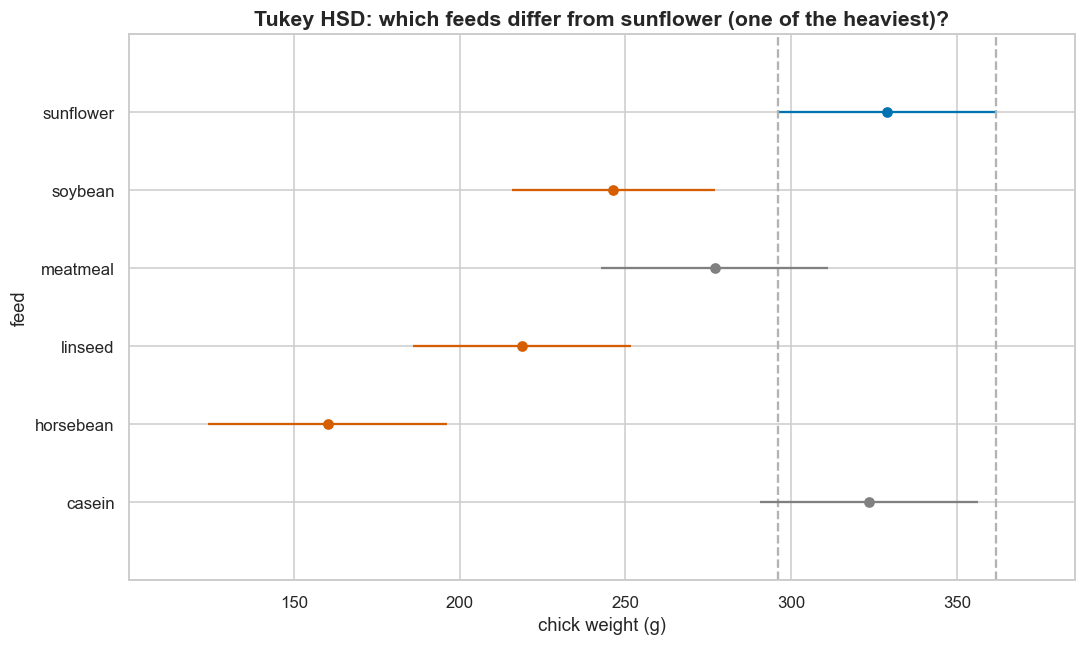

Each feed's band is its mean +/- a family-wise-adjusted margin. Bands that do NOT
overlap sunflower's shaded reference region differ significantly from sunflower.


In [12]:
fig = tukey.plot_simultaneous(comparison_name='sunflower', xlabel='chick weight (g)', ylabel='feed')
ax = plt.gca()
ax.set_title('Tukey HSD: which feeds differ from sunflower (one of the heaviest)?')
plt.tight_layout(); plt.show()
print("Each feed's band is its mean +/- a family-wise-adjusted margin. Bands that do NOT")
print("overlap sunflower's shaded reference region differ significantly from sunflower.")

The plot ranks the feeds left-to-right by mean weight and shades sunflower's reference region. Casein's
band overlaps it (statistically tied with sunflower), while horsebean and linseed sit far to the left,
clear of the shading — significantly lighter. That single picture captures what 15 separate t-tests
would have tried (and risked corrupting) to tell you, all at one honest 5% error rate.

## 7) The fine print: ANOVA's assumptions

Like every test, ANOVA trusts a few conditions. Worth knowing what they are and how to eyeball them:

1. **Independence** — observations don't influence each other (each chick weighed once, and — crucially
   here — *randomly assigned* to its feed). This is about *how the data was collected*; no plot can
   rescue a violation, so it matters most. The random assignment is also what earns us the causal
   reading from section 3.
2. **Roughly equal variances** across groups (*homoscedasticity*). Classic ANOVA assumes each group has
   about the same spread. Compare the group SDs, or use **Levene's test**.
3. **Approximately normal residuals** — the leftover wobble *within* groups should be roughly
   bell-shaped. With the Central Limit Theorem helping, ANOVA is forgiving of mild non-normality; a
   histogram is the quick check.

Let's run the two quantitative checks.

Group standard deviations (chick weight, g):
  casein     n= 12   SD =  64.4
  horsebean  n= 10   SD =  38.6
  linseed    n= 12   SD =  52.2
  meatmeal   n= 11   SD =  64.9
  soybean    n= 14   SD =  54.1
  sunflower  n= 12   SD =  48.8

Levene test for equal variances:  stat = 0.75,  p = 0.5896
  (p > 0.05 -> no strong evidence the spreads differ; equal-variance assumption is reasonable.)


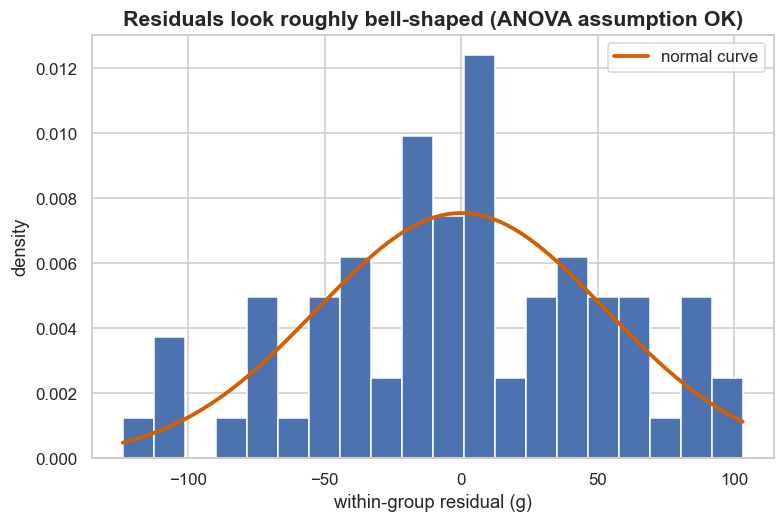

In [13]:
# Assumption 2: are the group spreads similar?
print('Group standard deviations (chick weight, g):')
for f in feed_order:
    g = ch.loc[ch['feed'] == f, 'weight']
    print(f'  {f:<10} n={len(g):>3}   SD = {g.std(ddof=1):5.1f}')

lev_stat, lev_p = stats.levene(*groups)
print(f'\nLevene test for equal variances:  stat = {lev_stat:.2f},  p = {lev_p:.4f}')
verdict = ('p < 0.05 -> REJECT equal variances: the spreads differ more than chance would explain.'
           if lev_p < 0.05 else
           'p > 0.05 -> no strong evidence the spreads differ; equal-variance assumption is reasonable.')
print(f'  ({verdict})')

# Assumption 3: are the within-group residuals roughly normal?
residuals = np.concatenate([g - g.mean() for g in groups])
fig, ax = plt.subplots()
ax.hist(residuals, bins=20, color='#4c72b0', edgecolor='white', density=True)
xs = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(xs, stats.norm.pdf(xs, 0, residuals.std(ddof=1)), color='#D55E00', lw=2.5,
        label='normal curve')
ax.set_xlabel('within-group residual (g)'); ax.set_ylabel('density')
ax.set_title('Residuals look roughly bell-shaped (ANOVA assumption OK)')
ax.legend(); plt.show()

The residuals are reasonably bell-shaped, and Levene's test gives a large p-value, so the
**equal-variance** assumption is comfortable here — cleaner than the penguins, where Levene's test
actually *rejected* equal variances ($p \approx 0.006$) and pushed us toward Welch's ANOVA. With the
chicks, plain one-way ANOVA's conditions hold up, the group sizes are nearly balanced (10–14 each), and
the omnibus signal is strong. The "feed matters, and here is the ranking" conclusion is on solid
ground.

## Now you try

Predict first, then change a number and re-run:

1. **Feel the trap at six and beyond.** In section 2, change the loop to `[2, 6, 15, 30]`. Before
   running, guess: at 30 identical groups, will the family-wise false-alarm rate be above or below 99%?
   Then check. (Thirty groups means $\binom{30}{2} = 435$ pairwise tests!)

2. **Re-derive the headline figure.** In section 1 we got $1 - 0.95^{15} \approx 0.54$ for six feeds.
   In a new cell, compute the same thing for **3** groups ($1 - 0.95^3$) and **10** groups
   ($1 - 0.95^{45}$). How fast does the false-discovery risk balloon as groups are added?

3. **Drop a feed, watch F change.** Run ANOVA on only the four heavier feeds (casein, meatmeal,
   soybean, sunflower), excluding horsebean and linseed:

       sub = ch[ch['feed'].isin(['casein', 'meatmeal', 'soybean', 'sunflower'])]
       gs = [sub.loc[sub['feed'] == f, 'weight'] for f in
             ['casein', 'meatmeal', 'soybean', 'sunflower']]
       print(stats.f_oneway(*gs))

   Predict the p-value first — still significant, or does removing the extreme horsebean group weaken
   the signal a lot?

4. **Re-roll the worlds.** Change `np.random.default_rng(0)` in section 2 to another number. Do the
   FWER percentages move much, or are they stable across seeds? (They should be stable — that's what
   makes it a *rate*.)

## What you learned

- **Running many pairwise t-tests inflates the false-positive rate**, and *more groups makes it much
  worse*: six feeds force **15** comparisons, giving a roughly $1-0.95^{15} \approx 54\%$ chance of at
  least one false "significant" even when every feed is identical — versus only ~14% for the penguins'
  three groups. You both *computed* this figure and *simulated* the true (correlated) rate, which sits
  below the $1-(1-\alpha)^m$ upper bound but still far above 5%.
- **One-way ANOVA** answers "**is any feed mean different?**" with a single test at a controlled 5%
  error rate, so it sidesteps that trap.
- ANOVA splits variation into **between-group** and **within-group** parts; the **F-statistic**
  $= MS_{\text{between}}/MS_{\text{within}}$ is large when group means are spread far apart relative to
  within-group noise. For the chicks $F \approx 15.4$ with $p \approx 6\times10^{-10}$ — overwhelming,
  even though it is far smaller than the penguins' $F \approx 343$.
- The **F-distribution** (with $k-1 = 5$ and $N-k$ degrees of freedom) is the reference for the p-value
  — and you rebuilt it from scratch by **shuffling labels**.
- $H_0$ is "all six means equal"; a significant result means **at least one** differs — not which. With
  two groups, ANOVA is exactly the two-sample t-test ($F = t^2$).
- **Tukey HSD** pinpoints *which* pairs differ while holding the family-wise error at 5%; here **8 of
  15 pairs** separate — horsebean (lightest) differs from the heavy feeds, while casein and sunflower
  (the two heaviest) are statistically tied.
- Because Chickwts is a **designed experiment with random assignment**, a significant ANOVA supports a
  genuinely **causal** reading — the feed *causes* the weight difference — unlike the **observational**
  penguins, where the same test only establishes association.
- ANOVA assumes **independence**, **roughly equal variances**, and **approximately normal residuals**;
  for the chicks all three hold comfortably (Levene's test does *not* reject equal variances), so plain
  one-way ANOVA is on firm footing.

---

**↩ Back to the lesson:** [Lesson 16: Comparing many groups: ANOVA](16-anova.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](16-anova~the-code.ipynb)